In [1]:
%pip install pandas matplotlib seaborn python-dotenv
%load_ext autoreload
%autoreload 2

  Using cached python_dotenv-1.2.3-py3-none-any.whl.metadata (29 kB)
Using cached python_dotenv-1.2.3-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Route Python to the main project folder
sys.path.append(os.path.abspath('..'))

# Load environment variables
load_dotenv()

# Import generic modules from the framework
from src.data_fetcher import load_data 
from src.data_profiling import generate_quality_report, clean_data
from src.data_processing import engineer_features
from src.analysis import generate_single_level_interactions, generate_refined_interactions
from src.visualization import generate_visualizations

# Set visual style for charts
sns.set_theme(style="whitegrid")

In [3]:
# 1. Fetch the raw dataset dynamically based on .env configuration
df_raw = load_data()

# Preview the first 5 rows to understand the structure
display(df_raw.head())

# 2. Generate the initial quality report
generate_quality_report(df_raw)

Loading data from: c:\Users\echatma\OneDrive - Ericsson\C_backup\official\personal\Self-development\Code Repo\BA\Generic_data_framework\data\raw\airline_loyalty.zip
Extracting 'Customer Loyalty History.csv' from archive...


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN



       DATA QUALITY REPORT

Number of duplicate rows found: 0
No duplicate rows detected.
----------------------------------------

--- Missing Values Summary ---
                    Missing Count  Percentage (%)
Salary                       4238           25.32
Cancellation Year           14670           87.65
Cancellation Month          14670           87.65

--- Counts of 'unknown' entries per column ---
No 'unknown' text entries detected.
----------------------------------------

'Country': 1 distinct categories total. (Top 5 most frequent):
Country
Canada    16737
Name: count, dtype: int64

'Province': 11 distinct categories total. (Top 5 most frequent):
Province
Ontario             5404
British Columbia    4409
Quebec              3300
Alberta              969
Manitoba             658
Name: count, dtype: int64

'City': 29 distinct categories total. (Top 5 most frequent):
City
Toronto      3351
Vancouver    2582
Montreal     2059
Winnipeg      658
Whistler      582
Name: count, d

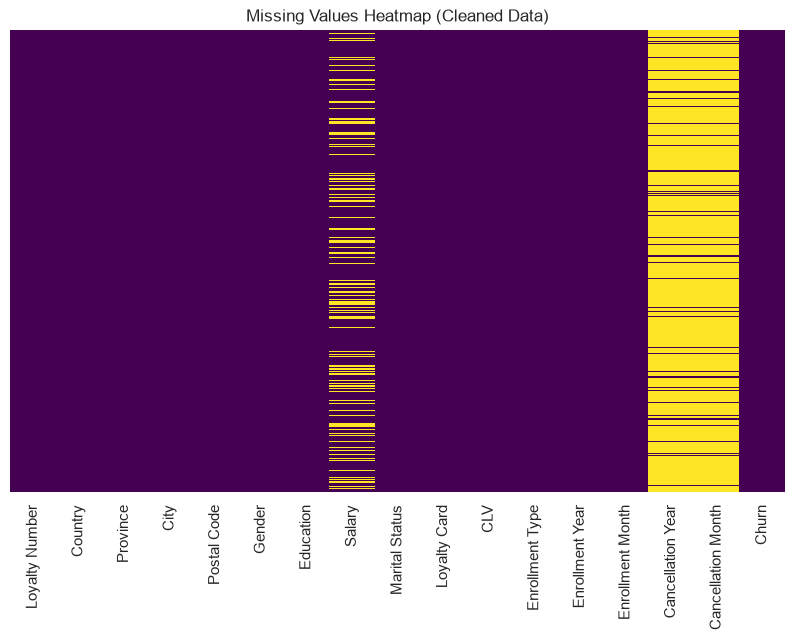

In [4]:
# 3. Clean the dataset (removes duplicates, handles null placeholders, standardizes text)
df_clean = clean_data(df_raw)

# 4. Engineer target features dynamically based on .env configuration
df_final = engineer_features(df_clean)

# Visualize missing values across the cleaned and engineered dataset
plt.figure(figsize=(10, 6))
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap (Cleaned Data)")
plt.show()

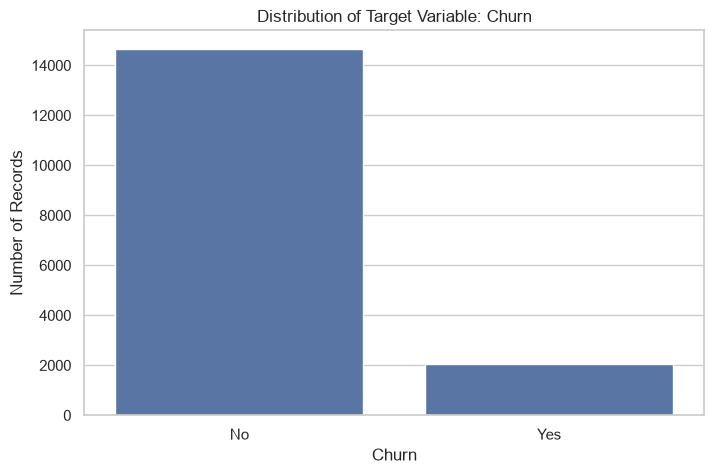

Churn
No     14670
Yes     2067
Name: count, dtype: int64

In [5]:
# Dynamically fetch the target column from the .env configuration
target_col = os.getenv("TARGET_COL")

if target_col and target_col in df_final.columns:
    # Analyze the distribution of the generic Target Variable
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_final, x=target_col, order=df_final[target_col].value_counts().index)
    plt.title(f"Distribution of Target Variable: {target_col}")
    plt.ylabel("Number of Records")
    plt.show()

    # Print exact counts 
    display(df_final[target_col].value_counts())
else:
    print(f"Target column '{target_col}' not found in dataset. Please check your .env file or feature engineering rules.")

In [6]:
# 5. Execute the automated data analysis and visualization pipeline
print("Generating Single Level Interactions...")
generate_single_level_interactions(df_final)

print("\nGenerating Refined Interactions (Dual-Scenarios)...")
generate_refined_interactions(df_final)

print("\nGenerating Analytical Figures...")
generate_visualizations(df_final)

print("\nGeneric Pipeline execution complete. Check outputs/reports and outputs/figures.")

Generating Single Level Interactions...
Single-level structured tables saved to: c:\Users\echatma\OneDrive - Ericsson\C_backup\official\personal\Self-development\Code Repo\BA\Generic_data_framework\outputs\reports\single_interactions

Generating Refined Interactions (Dual-Scenarios)...
Refined interaction structured tables saved to: c:\Users\echatma\OneDrive - Ericsson\C_backup\official\personal\Self-development\Code Repo\BA\Generic_data_framework\outputs\reports\interaction_output

Generating Analytical Figures...
Analytical charts (Dual-Scenarios & Trends) generated successfully in: c:\Users\echatma\OneDrive - Ericsson\C_backup\official\personal\Self-development\Code Repo\BA\Generic_data_framework\outputs\figures

Generic Pipeline execution complete. Check outputs/reports and outputs/figures.
